## Ensemble Learning

In [1]:
# import the required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# prerequisities
import warnings
warnings.filterwarnings(action="ignore")

In [3]:
df=pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [6]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [8]:
df.drop(['User ID'],axis=1,inplace=True)

In [9]:
# convert the gender column
from sklearn.preprocessing import LabelEncoder
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

In [10]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


In [11]:
df.corr()

,Gender,Age,EstimatedSalary,Purchased
Gender,1.000000,-0.073741,-0.060435,-0.042469
Age,-0.073741,1.000000,0.155238,0.622454
EstimatedSalary,-0.060435,0.155238,1.000000,0.362083
Purchased,-0.042469,0.622454,0.362083,1.000000


In [12]:
# create x
x=df.drop(['Purchased','Gender'],axis=1)

# create y
y=df['Gender']

In [13]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=123456)

## Build the Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

model_random=RandomForestClassifier(n_estimators=50)

model_random.fit(x_train,y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## grid search

## Evaluation metrics

In [21]:
from sklearn.tree import DecisionTreeClassifier

# 1. Define and train the model
model_decision = DecisionTreeClassifier()
model_decision.fit(x_train, y_train)

# 2. Now you can predict (Line 1 in your error)
y_pred = model_decision.predict(x_test)

# 3. Evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Calculate all metrics first
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 2. Now you can print them safely
print(f"Accuracy = {accuracy:.2f}")
print(f"Precision = {precision:.2f}")
print(f"Recall = {recall:.2f}")
print(f"F1 Score = {f1:.2f}")


Accuracy = 0.51
Precision = 0.51
Recall = 0.45
F1 Score = 0.48


In [24]:
y_pred=model_random.predict(x_test)
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [25]:
print(f"Accuracy ={accuracy:.2f}")
print(f"Precision ={precision:.2f}")
print(f"Recall ={recall:.2f}")
print(f"F1 Score ={f1:.2f}")

Accuracy =0.51
Precision =0.51
Recall =0.57
F1 Score =0.54


## Data Visualization

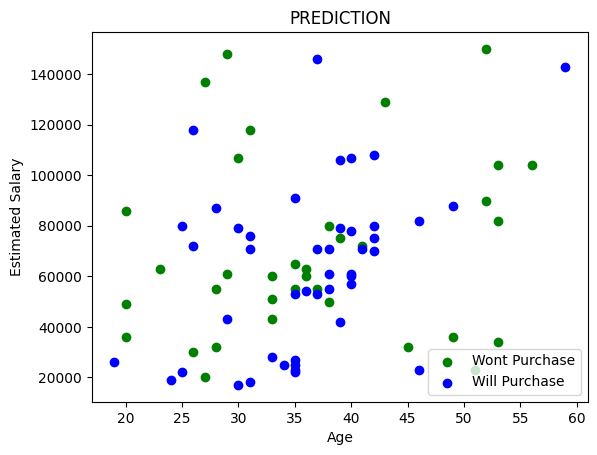

In [27]:
plt.scatter(x_test['Age'][y_pred==0],x_test['EstimatedSalary'][y_pred==0],label="Wont Purchase",color="green")
plt.scatter(x_test['Age'][y_pred==1],x_test['EstimatedSalary'][y_pred==1],label="Will Purchase",color="blue")

plt.title("PREDICTION")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()

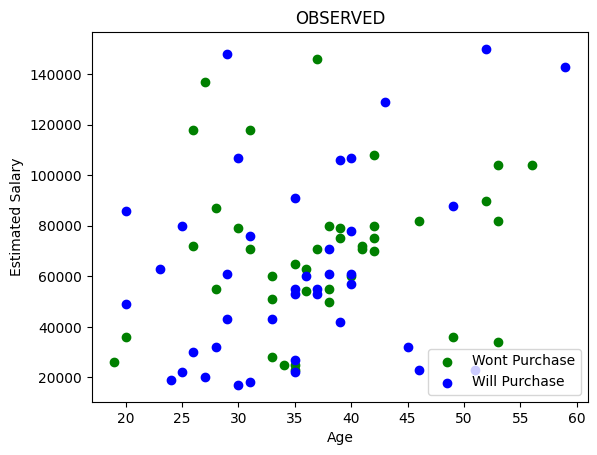

In [28]:
plt.scatter(x_test['Age'][y_test==0],x_test['EstimatedSalary'][y_test==0],label="Wont Purchase",color="green")
plt.scatter(x_test['Age'][y_test==1],x_test['EstimatedSalary'][y_test==1],label="Will Purchase",color="blue")

plt.title("OBSERVED")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()

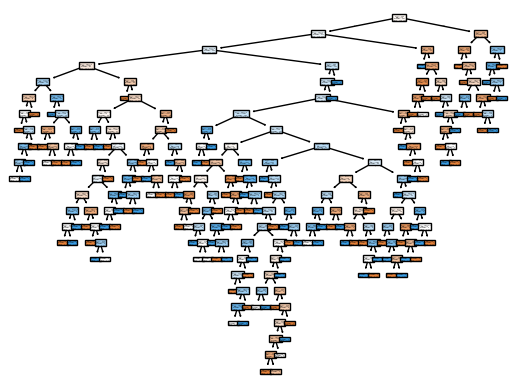

In [29]:
# tree visualization

from sklearn.tree import plot_tree

tree =plot_tree(model_decision,max_depth=50,filled=True)

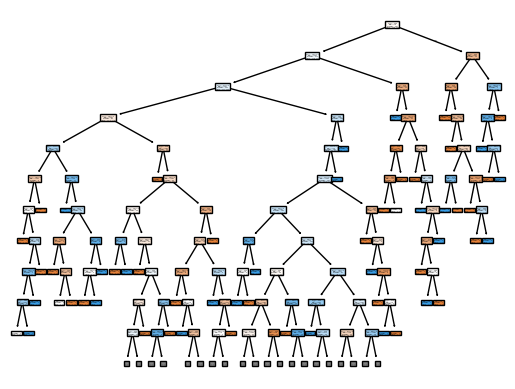

In [30]:
# tree visualization

from sklearn.tree import plot_tree

tree =plot_tree(model_decision,max_depth=10,filled=True)

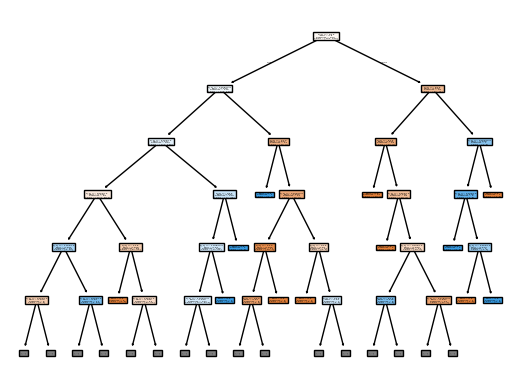

In [31]:
# tree visualization

from sklearn.tree import plot_tree

tree =plot_tree(model_decision,max_depth=5,filled=True)